# Week 2 · Day 2 — 侵蚀分割数据集构建与验证

**数据来源**：Day 1 生成的 `img_XXXX.npy`（原始 DN 值）+ `mask_XXXX.npy`  
**输出**：`DataLoader` → `image (B,6,224,224)` + `mask (B,1,224,224)`

In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import time

PATCH_DIR = Path(r'D:\geology AI\data\processed\week2_patches')
FIG_DIR   = Path(r'D:\geology AI\results\figures')

MEAN = np.array([343.4, 546.8, 444.1, 2942.5, 1444.6, 899.7], dtype=np.float32)
STD  = np.array([255.0, 340.6, 373.0, 1232.4,  852.0, 680.1], dtype=np.float32)

img_files = sorted(PATCH_DIR.glob('img_*.npy'))
print(f'找到 {len(img_files)} 个 patch')
if len(img_files) == 0:
    print('⚠ 请先运行 05_spectral_labels.ipynb 生成 patch')

找到 200 个 patch


## 2.1 ErosionDataset 定义

In [2]:
class ErosionDataset(Dataset):
    """
    读取 Day 1 生成的 patch 对。
    返回:
      image : (6, 224, 224)  float32，已归一化（与 Week 1 MEAN/STD 一致）
      mask  : (1, 224, 224)  float32，0=无侵蚀 / 1=侵蚀
    """
    def __init__(self, patch_dir, augment=True):
        self.patch_dir = Path(patch_dir)
        self.augment   = augment
        self.indices   = sorted(
            int(p.stem.split('_')[1])
            for p in self.patch_dir.glob('img_*.npy')
        )
        assert len(self.indices) > 0, '先运行 05_spectral_labels.ipynb'
        print(f'ErosionDataset: {len(self.indices)} 个样本')

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        img  = np.load(self.patch_dir / f'img_{i:04d}.npy').astype(np.float32)   # (6,224,224)
        mask = np.load(self.patch_dir / f'mask_{i:04d}.npy').astype(np.float32)  # (224,224)

        # 归一化（与 Week 1 notebook 04 相同）
        img = (img - MEAN[:, None, None]) / STD[:, None, None]

        # 数据增强
        if self.augment:
            if np.random.rand() > 0.5:
                img  = img[:, :, ::-1].copy()
                mask = mask[:, ::-1].copy()
            if np.random.rand() > 0.5:
                img  = img[:, ::-1, :].copy()
                mask = mask[::-1, :].copy()

        return (torch.from_numpy(img),
                torch.from_numpy(mask).unsqueeze(0))


full_ds = ErosionDataset(PATCH_DIR)

ErosionDataset: 200 个样本


## 2.2 单样本验证

In [3]:
img_t, mask_t = full_ds[0]
print(f'image : {img_t.shape}  dtype={img_t.dtype}  mean={img_t.mean():.3f}  std={img_t.std():.3f}')
print(f'mask  : {mask_t.shape}  dtype={mask_t.dtype}  unique={mask_t.unique().tolist()}')
print(f'侵蚀像素占比: {mask_t.mean():.3f}')

assert img_t.shape  == (6, 224, 224), f'期望 (6,224,224) 实际 {img_t.shape}'
assert mask_t.shape == (1, 224, 224), f'期望 (1,224,224) 实际 {mask_t.shape}'
print('\n✓ 形状验证通过')

image : torch.Size([6, 224, 224])  dtype=torch.float32  mean=1.373  std=3.734
mask  : torch.Size([1, 224, 224])  dtype=torch.float32  unique=[0.0, 1.0]
侵蚀像素占比: 0.194

✓ 形状验证通过


## 2.3 类别不平衡分析

样本数:        200
平均侵蚀占比:  0.203  (20.3%)
中位数:        0.193
建议 pos_weight = 3.92  （复制到 Day 4 训练配置）


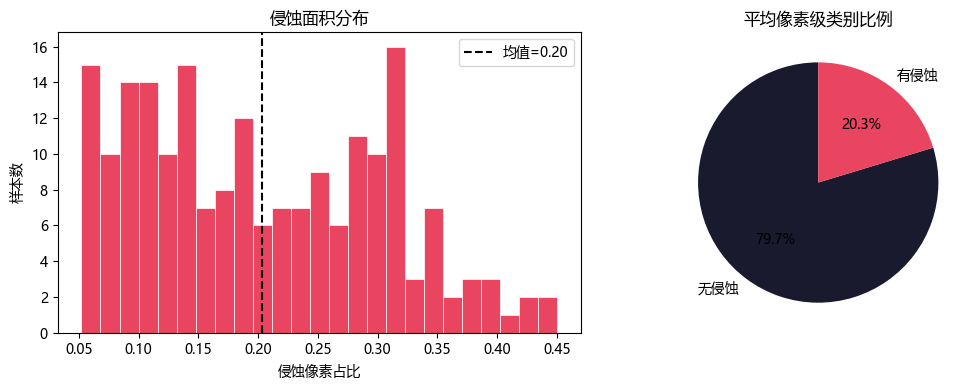

In [4]:
erosion_pcts = np.array([full_ds[i][1].mean().item() for i in range(len(full_ds))])

pos_weight = (1 - erosion_pcts.mean()) / erosion_pcts.mean()
print(f'样本数:        {len(full_ds)}')
print(f'平均侵蚀占比:  {erosion_pcts.mean():.3f}  ({erosion_pcts.mean()*100:.1f}%)')
print(f'中位数:        {np.median(erosion_pcts):.3f}')
print(f'建议 pos_weight = {pos_weight:.2f}  （复制到 Day 4 训练配置）')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(erosion_pcts, bins=25, color='#e94560', edgecolor='white', lw=0.5)
ax1.axvline(erosion_pcts.mean(), color='black', ls='--', label=f'均值={erosion_pcts.mean():.2f}')
ax1.set_xlabel('侵蚀像素占比'); ax1.set_ylabel('样本数'); ax1.set_title('侵蚀面积分布'); ax1.legend()

ax2.pie([(1-erosion_pcts.mean()), erosion_pcts.mean()],
        labels=['无侵蚀','有侵蚀'], autopct='%1.1f%%',
        colors=['#1a1a2e','#e94560'], startangle=90)
ax2.set_title('平均像素级类别比例')
plt.tight_layout()
plt.savefig(FIG_DIR / 'week2_06_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 构建 DataLoader

In [5]:
torch.manual_seed(42)
n_val   = max(1, int(len(full_ds) * 0.2))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train: {len(train_ds)} 样本 / {len(train_loader)} batch')
print(f'Val:   {len(val_ds)}   样本 / {len(val_loader)}   batch')

t0 = time.time()
imgs, masks = next(iter(train_loader))
print(f'\nBatch → image {imgs.shape}  mask {masks.shape}')
print(f'加载耗时: {time.time()-t0:.2f}s')

Train: 160 样本 / 40 batch
Val:   40   样本 / 10   batch

Batch → image torch.Size([4, 6, 224, 224])  mask torch.Size([4, 1, 224, 224])
加载耗时: 0.36s


## 2.5 Batch 可视化

注意：**Week 1 归一化参数** 反归一化后显示 RGB

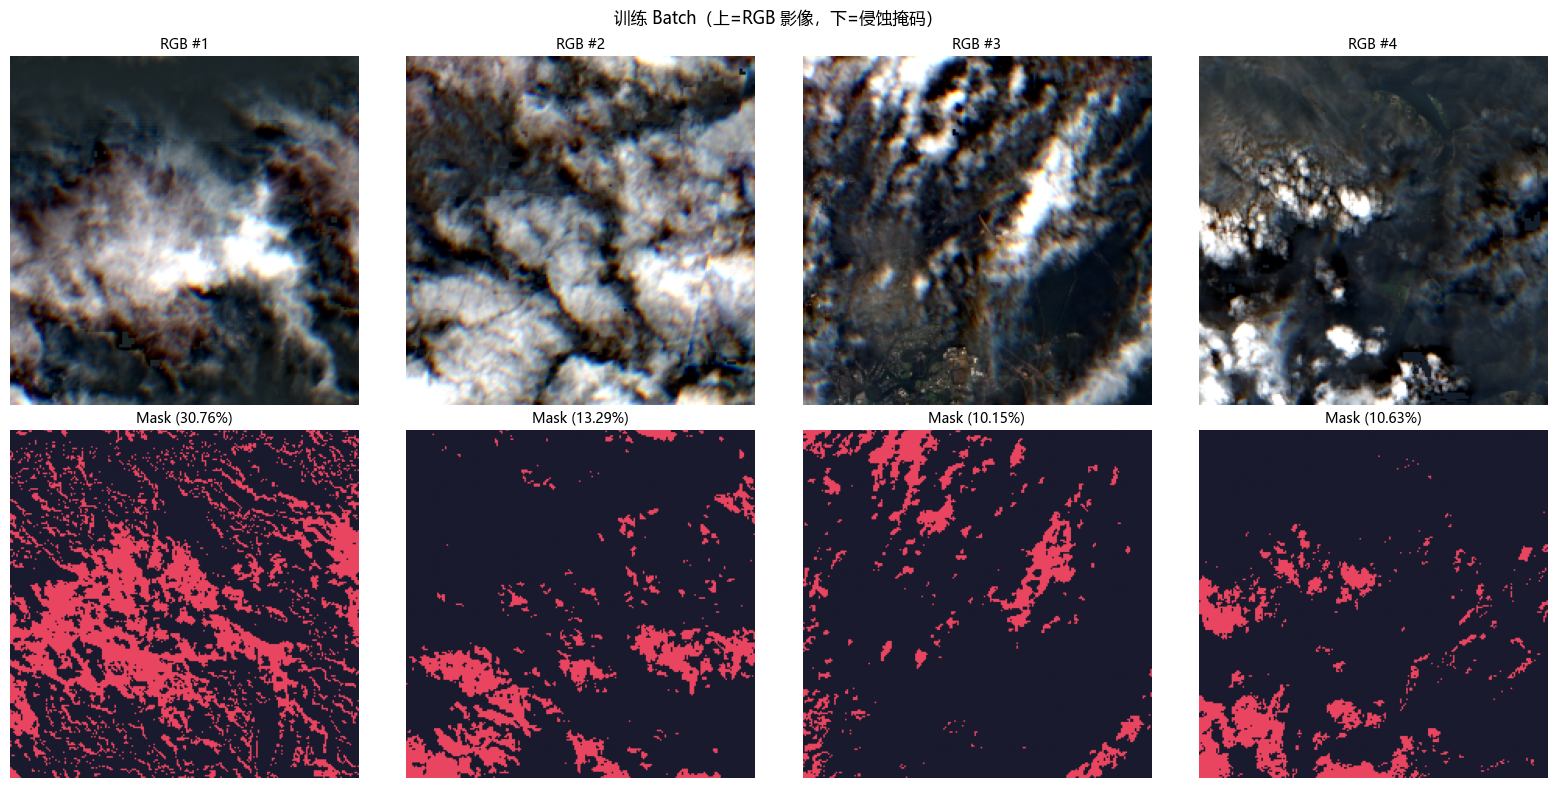

✓ Day 2 完成


In [6]:
import matplotlib.colors as mcolors

def denorm(img_t):
    """(6,H,W) tensor → (H,W,3) RGB uint8"""
    img = img_t.numpy() * STD[:, None, None] + MEAN[:, None, None]  # 反归一化
    rgb = img[[2, 1, 0]].copy()  # B04 B03 B02
    for i in range(3):
        lo, hi = np.percentile(rgb[i], [2, 98])
        rgb[i]  = np.clip((rgb[i] - lo) / (hi - lo + 1e-8), 0, 1)
    return rgb.transpose(1, 2, 0)

B = imgs.shape[0]
cmap_e = mcolors.ListedColormap(['#1a1a2e', '#e94560'])
fig, axes = plt.subplots(2, B, figsize=(4*B, 8))

for i in range(B):
    axes[0, i].imshow(denorm(imgs[i]))
    axes[0, i].set_title(f'RGB #{i+1}', fontsize=10); axes[0, i].axis('off')
    axes[1, i].imshow(masks[i, 0].numpy(), cmap=cmap_e, vmin=0, vmax=1)
    axes[1, i].set_title(f'Mask ({masks[i].mean():.2%})', fontsize=10); axes[1, i].axis('off')

plt.suptitle('训练 Batch（上=RGB 影像，下=侵蚀掩码）', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week2_06_batch_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Day 2 完成')

---
## 💾 保存到 GitHub

In [7]:
import subprocess, os
from pathlib import Path

REPO_DIR = r'D:\geology AI'
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)

git('git add notebooks/06_erosion_dataset.ipynb')
git('git add results/figures/week2_06_class_balance.png')
git('git add results/figures/week2_06_batch_preview.png')
git('git commit -m "Week2 Day2: ErosionDataset + DataLoader validated + class imbalance analysis"')
git('git push origin main')
print('\n✓ 已推送到 GitHub')

[main 8ad649a] Week2 Day2: ErosionDataset + DataLoader validated + class imbalance analysis
 3 files changed, 248 insertions(+)
 create mode 100644 notebooks/06_erosion_dataset.ipynb
 create mode 100644 results/figures/week2_06_batch_preview.png
 create mode 100644 results/figures/week2_06_class_balance.png
To https://github.com/lofophil/geo-foundation-experiments.git
   5d7f698..8ad649a  main -> main

✓ 已推送到 GitHub
